In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression, SGDRegressor,LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

```text
특성데이터: 가격분류 제외한 나머지
라벨: 가격분류

In [2]:
Hdf = pd.read_excel('../data/현대자동차.xlsx')
Hdf

,가격,년식,종류,연비,마력,토크,연료,하이브리드,배기량,중량,변속기,가격분류
0,1885,2015,준중형,11.8,172,21.0,가솔린,0,1999,1300,자동,일반
1,2190,2015,준중형,12.3,204,27.0,가솔린,0,1591,1300,자동,고가
2,1135,2015,소형,15.0,100,13.6,가솔린,0,1368,1035,수동,일반
3,1645,2014,소형,14.0,140,17.0,가솔린,0,1591,1090,자동,일반
4,1960,2015,대형,9.6,175,46.0,디젤,0,2497,1990,자동,일반
...,...,...,...,...,...,...,...,...,...,...,...,...
66,3802,2015,중형,8.5,290,34.8,가솔린,0,3342,1901,자동,고가
67,1270,2012,소형,13.3,108,13.9,가솔린,0,1396,1040,자동,일반
68,2430,2015,준중형,12.8,186,41.0,디젤,0,1995,1665,자동,고가
69,2870,2015,중형,17.7,156,19.3,가솔린,1,1999,1585,자동,고가


In [3]:
x_data = Hdf.iloc[:,:-1]
y_data = Hdf.iloc[:,[-1]]

1. 상관관계를 구하시요

In [4]:
num_cols = ['가격','년식','연비','마력','토크','하이브리드','배기량','중량']

In [5]:
cat_cols = ['종류','연료','변속기']

In [6]:
Hdf_dummy = pd.get_dummies(Hdf[cat_cols], drop_first=True, dtype=int)

In [7]:
pd.get_dummies(Hdf[['종류','연료','변속기']], dtype=int)

,종류_대형,종류_소형,종류_준중형,종류_중형,연료_LPG,연료_가솔린,연료_디젤,변속기_수동,변속기_자동
0,0,0,1,0,0,1,0,0,1
1,0,0,1,0,0,1,0,0,1
2,0,1,0,0,0,1,0,1,0
3,0,1,0,0,0,1,0,0,1
4,1,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...
66,0,0,0,1,0,1,0,0,1
67,0,1,0,0,0,1,0,0,1
68,0,0,1,0,0,0,1,0,1
69,0,0,0,1,0,1,0,0,1


In [8]:
corr_df = pd.concat([Hdf[num_cols], Hdf_dummy], axis=1)

In [9]:
corr_df.corr()

,가격,년식,연비,마력,토크,하이브리드,배기량,중량,종류_소형,종류_준중형,종류_중형,연료_가솔린,연료_디젤,변속기_자동
가격,1.000000,0.378237,-0.345488,0.893995,0.565016,0.043974,0.852247,0.517288,-0.438728,-0.157510,0.175226,0.059893,-0.004273,0.326464
년식,0.378237,1.000000,-0.354930,0.485245,0.538361,-0.079089,0.451284,0.569321,-0.697305,0.162189,0.240789,-0.308995,0.366423,0.181793
연비,-0.345488,-0.354930,1.000000,-0.499384,-0.260482,0.237268,-0.659503,-0.698694,0.473661,0.260759,0.071571,0.164325,0.028593,-0.182552
마력,0.893995,0.485245,-0.499384,1.000000,0.662249,-0.112834,0.909100,0.618218,-0.562641,-0.109979,0.164217,0.026735,0.033106,0.303948
토크,0.565016,0.538361,-0.260482,0.662249,1.000000,-0.191790,0.616431,0.743632,-0.635442,-0.011317,0.223965,-0.559486,0.661371,0.131063
하이브리드,0.043974,-0.079089,0.237268,-0.112834,-0.191790,1.000000,-0.052107,-0.034522,-0.113288,0.062809,0.071876,0.067062,-0.179670,0.131533
배기량,0.852247,0.451284,-0.659503,0.909100,0.616431,-0.052107,1.000000,0.752350,-0.573032,-0.257705,0.022580,-0.073506,0.063345,0.215127
중량,0.517288,0.569321,-0.698694,0.618218,0.743632,-0.034522,0.752350,1.000000,-0.769690,-0.217420,0.188455,-0.590152,0.508567,0.125033
종류_소형,-0.438728,-0.697305,0.473661,-0.562641,-0.635442,-0.113288,-0.573032,-0.769690,1.000000,-0.279145,-0.267304,0.464389,-0.393124,-0.186824
종류_준중형,-0.157510,0.162189,0.260759,-0.109979,-0.011317,0.062809,-0.257705,-0.217420,-0.279145,1.000000,-0.256495,-0.110810,0.116089,-0.059419


2. train, test 분할

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, 
                                                    test_size=0.3, stratify=y_data)

3. 3065	2015	중형	13.8	200	44.5	디젤	0	2199	1799	자동 : 가격분류 예측하시요

In [11]:
h_list = [('scale',StandardScaler(),['가격','년식','연비','마력','토크','하이브리드','배기량','중량']),
        ('enc',OneHotEncoder(handle_unknown='ignore'),['종류','연료','변속기'])]

In [12]:
h_preprocessor = ColumnTransformer( h_list,
                                        remainder='passthrough')

In [13]:
model_cpipe = Pipeline( [ ('ct', h_preprocessor),
                        ('logi', LogisticRegression()) ] )

model_cpipe.fit(x_train, y_train)

c:\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('ct', ...), ('logi', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scale', ...), ('enc', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
xd = pd.DataFrame({'가격':[3065],'년식':[2015],'종류':['중형'],'연비':[13.8],'마력':[200],'토크':[44.5],'연료':['디젤'],'하이브리드':[0],'배기량':[2199],'중량':[1799],'변속기':['자동']})
model_cpipe.predict(xd)

array(['고가'], dtype=object)

4. train, test  : confusion matrix, 정확도, 정밀도, 재현율, f1 score , roc 를 구하시요

In [15]:
x_data = Hdf.iloc[:, :-1]
y_data = Hdf.iloc[:, -1]

In [16]:
pred = model_cpipe.predict(x_train)
pred

array(['고가', '일반', '고가', '고가', '일반', '고가', '고가', '일반', '고가', '일반', '일반',
       '일반', '일반', '일반', '고가', '고가', '일반', '일반', '고가', '일반', '일반', '일반',
       '고가', '고가', '고가', '고가', '일반', '일반', '고가', '고가', '고가', '고가', '고가',
       '고가', '일반', '고가', '고가', '고가', '고가', '일반', '고가', '일반', '고가', '고가',
       '일반', '일반', '일반', '일반', '고가'], dtype=object)

In [17]:
pred_tt = model_cpipe.predict(x_test)
pred_tt

array(['일반', '고가', '고가', '고가', '일반', '고가', '일반', '고가', '일반', '고가', '일반',
       '일반', '일반', '고가', '일반', '고가', '일반', '일반', '고가', '고가', '고가', '고가'],
      dtype=object)

In [18]:
c = confusion_matrix(y_train, pred)

In [19]:
c_t = confusion_matrix(y_test, pred_tt)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_curve, auc

In [21]:
print('정확도', accuracy_score(y_train, pred))
print('정밀도', precision_score(y_train, pred, pos_label='고가'))
print('재현율', recall_score(y_train, pred, pos_label='고가'))
print('f1 score', f1_score(y_train, pred, pos_label='고가'))

print(confusion_matrix(y_train, pred, labels=['고가','일반']))

정확도 0.9795918367346939
정밀도 0.9629629629629629
재현율 1.0
f1 score 0.9811320754716981
[[26  0]
 [ 1 22]]


In [22]:
print(type(pred), set(pred))          # 라벨인지 확인
print(hasattr(model_cpipe, "predict_proba"), hasattr(model_cpipe, "decision_function"))
print(model_cpipe.classes_)           # 라벨 순서 확인

<class 'numpy.ndarray'> {'고가', '일반'}
True True
['고가' '일반']


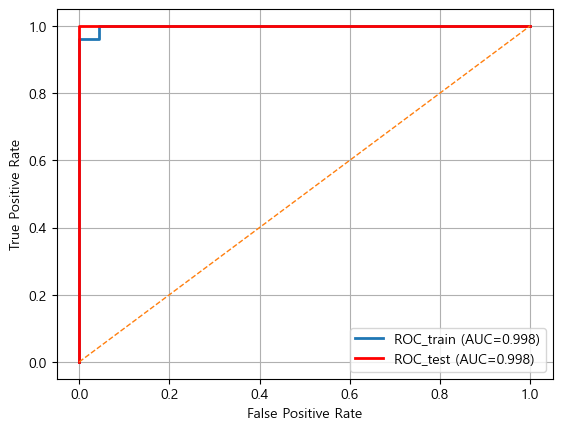

AUC: 0.9983277591973244
AUC_test: 1.0


In [23]:
# '고가' 확률 (classes_가 ['고가','일반'] 이므로 0번)
y_score = model_cpipe.predict_proba(x_train)[:, 0]
y_scoret = model_cpipe.predict_proba(x_test)[:, 0]

fpr, tpr, thresholds = roc_curve(y_train, y_score, pos_label='고가')
tfpr, ttpr, tthresholds = roc_curve(y_test, y_scoret, pos_label='고가')
auc_val = auc(fpr, tpr)
auc_val_test = auc(tfpr, ttpr)

plt.plot(fpr, tpr, lw=2, label=f'ROC_train (AUC={auc_val:.3f})')
plt.plot(tfpr, ttpr, lw=2,color='red', label=f'ROC_test (AUC={auc_val:.3f})')
plt.plot([0, 1], [0, 1], lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

print("AUC:", auc_val)
print("AUC_test:", auc_val_test)


In [24]:
print('정확도', accuracy_score(y_test, pred_tt))
print('정밀도', precision_score(y_test, pred_tt, pos_label='고가'))
print('재현율', recall_score(y_test, pred_tt, pos_label='고가'))
print('f1 score', f1_score(y_test, pred_tt, pos_label='고가'))

print(confusion_matrix(y_test, pred_tt, labels=['고가','일반']))

정확도 1.0
정밀도 1.0
재현율 1.0
f1 score 1.0
[[12  0]
 [ 0 10]]
